# Group 1 Baseline Workflow (Storyteller Notebook)

This notebook is the **clean orchestration layer** for Group 1 baseline.
All core logic lives in `src/`; notebook cells call those modules stage-by-stage.


## Stage Map

1. Setup and environment check
2. Data acquisition + prep (COCO -> alignment -> instruction format)
3. Tokenization (stage 1 and stage 2)
4. CLIP feature precompute
5. Manifest build
6. Stage 1 training
7. Stage 2 training
8. Artifacts + quick validation


In [1]:
from pathlib import Path
import json
import os
import sys

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent
CONFIG_PATH = PROJECT_ROOT / "configs" / "workflow_paths.json"
DOTENV_PATH = PROJECT_ROOT / ".env"

# Add project root once; import from src.* modules below.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config_loader import load_dotenv_file, load_json_config

load_dotenv_file(DOTENV_PATH)
print("PROJECT_ROOT =", PROJECT_ROOT)
print("CONFIG_PATH =", CONFIG_PATH)
print("HF_TOKEN loaded =", bool(os.environ.get("HF_TOKEN")))


PROJECT_ROOT = /root/final_project/group1_baseline
CONFIG_PATH = /root/final_project/group1_baseline/configs/workflow_paths.json
HF_TOKEN loaded = True


In [2]:
# Load central path config from configs/workflow_paths.json
cfg = load_json_config(CONFIG_PATH, PROJECT_ROOT)

Path(cfg["artifacts_dir"]).mkdir(parents=True, exist_ok=True)
print(json.dumps(cfg, indent=2))


{
  "tokenizer_id": "meta-llama/Llama-3.2-1B-Instruct",
  "coco_json": "/root/final_project/group1_baseline/data/raw/annotations/captions_train2017.json",
  "image_root": "/root/final_project/group1_baseline/data/raw/train2017",
  "stage1_alignment_json": "/root/final_project/group1_baseline/data/processed/stage1_alignment/alignment.json",
  "stage1_chat_json": "/root/final_project/group1_baseline/data/processed/stage1_alignment/alignment_chat.json",
  "stage1_tokenized_json": "/root/final_project/group1_baseline/data/processed/stage1_alignment/alignment_tokenized.json",
  "stage1_manifest_json": "/root/final_project/group1_baseline/data/processed/stage1_alignment/stage1_manifest.json",
  "stage2_input_json": "/root/final_project/group1_baseline/data/processed/stage2_finetuning/stage2_input.json",
  "stage2_tokenized_json": "/root/final_project/group1_baseline/data/processed/stage2_finetuning/alignment_tokenized_stage2.json",
  "stage2_manifest_json": "/root/final_project/group1_baseli

## Stage 0: Environment Check

Run this before heavy steps to confirm required imports are available.


### Checklist - Before Stage 0
- [ ] `.venv` is active and selected as notebook kernel
- [ ] `python scripts/check_env.py --profile all` passes in terminal
- [ ] `.env` exists and contains `HF_TOKEN`
- [ ] Config file exists: `configs/workflow_paths.json`


In [3]:
# Run from `code/group1_baseline` root in terminal if this cell fails:
# python scripts/check_env.py --profile core
# python scripts/check_env.py --profile notebook
# python scripts/check_env.py --profile tpu


## Stage 1: Data Acquisition + Prep (COCO -> Alignment -> Instruction Format)

Inputs:
- COCO data (downloaded if missing)

Outputs:
- `cfg["stage1_alignment_json"]`
- `cfg["stage1_chat_json"]`


### Checklist - Before Stage 1
- [ ] Enough disk space for COCO images + annotations
- [ ] `data/raw/` path is correct in config
- [ ] You understand overwrite policy (`overwrite=False` by default)
- [ ] If regenerating, delete old Stage 1 processed outputs first


In [4]:
from src.data_prep.stage1_pipeline import run_stage1_data_prep

coco_path = Path(cfg["coco_json"])
alignment_path = Path(cfg["stage1_alignment_json"])
chat_path = Path(cfg["stage1_chat_json"])

alignment, chat_rows, mode, status = run_stage1_data_prep(
    project_root=PROJECT_ROOT,
    coco_json_path=coco_path,
    alignment_path=alignment_path,
    chat_path=chat_path,
    seed=42,
    overwrite=False,
    download=True,
    extract=True,
)

for k, pth in status.items():
    print(f"{k}: {pth} -> {'OK' if pth.exists() else 'MISSING'}")

print(f"Stage 1 mode: {mode}")
print("alignment rows:", len(alignment))
print("chat rows:", len(chat_rows))
print("sample:", chat_rows[0] if chat_rows else "<empty>")


skip download (exists): /root/final_project/group1_baseline/data/raw/train2017.zip
skip download (exists): /root/final_project/group1_baseline/data/raw/annotations_trainval2017.zip
skip extract (exists): /root/final_project/group1_baseline/data/raw/train2017
skip extract (exists): /root/final_project/group1_baseline/data/raw/annotations/captions_train2017.json
train_zip: /root/final_project/group1_baseline/data/raw/train2017.zip -> OK
ann_zip: /root/final_project/group1_baseline/data/raw/annotations_trainval2017.zip -> OK
train_dir: /root/final_project/group1_baseline/data/raw/train2017 -> OK
ann_json: /root/final_project/group1_baseline/data/raw/annotations/captions_train2017.json -> OK
Stage 1 mode: loaded
alignment rows: 591753
chat rows: 591753
sample: {'image': '000000203564.jpg', 'instruction': 'Describe this image briefly.', 'response': 'A bicycle replica with a clock as the front wheel.'}


### Stage 1 Sanity Visualization

Show a few real images from `chat_rows` with prompt/response snippets.


image: 000000576301.jpg
instruction: Describe this image briefly.
response: A white toilet sitting in a restroom next to a sink. ...
-
image: 000000540509.jpg
instruction: Summarize this picture.
response: A ram and ewe on the side of a snow covered incline ...
-
image: 000000197118.jpg
instruction: What is in this image?
response: Two brown horses crossing necks with each other. ...
-
image: 000000350703.jpg
instruction: Summarize this picture.
response: A view of what a person sees as he is biking on the road. ...
-


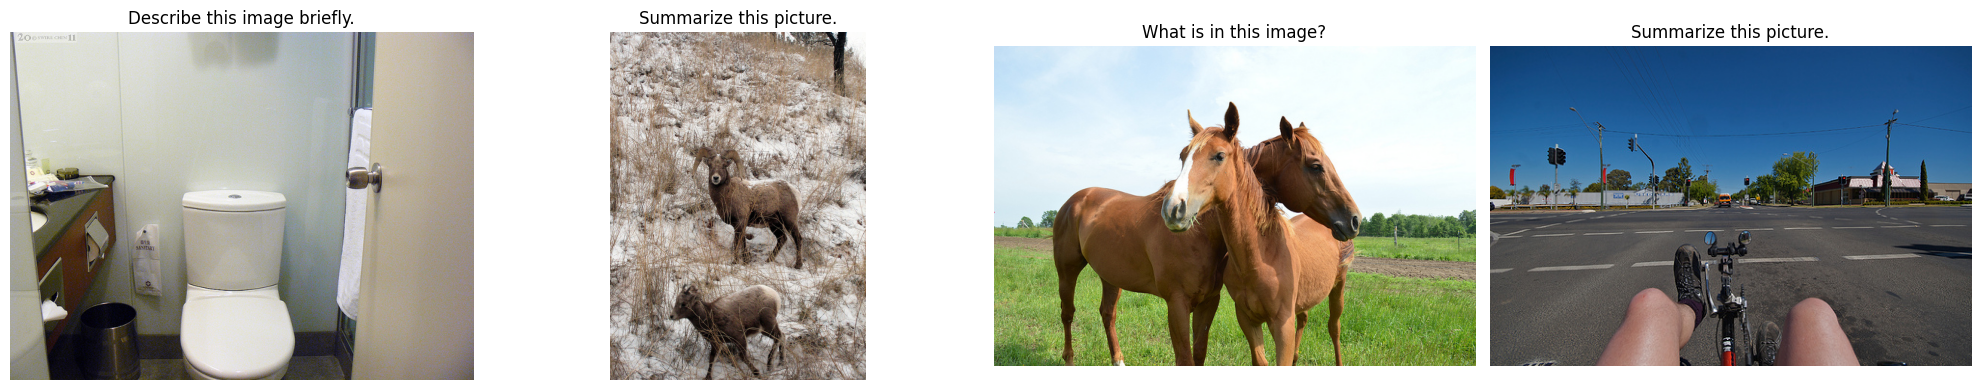

In [5]:
import random
from PIL import Image
import matplotlib.pyplot as plt

if not chat_rows:
    raise RuntimeError("chat_rows is empty; run Stage 1 first.")

n = min(4, len(chat_rows))
examples = random.sample(chat_rows, k=n)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, sample in zip(axes, examples):
    img_path = Path(cfg["image_root"]) / sample["image"]
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    title = sample["instruction"][:45]
    ax.set_title(title)
    print("image:", sample["image"])
    print("instruction:", sample["instruction"])
    print("response:", sample["response"][:140], "...")
    print("-")

plt.tight_layout()
plt.show()


## Stage 2: Tokenization (Executable)

This cell runs tokenization directly using `src.training.tokenization`.
- Always builds Stage 1 tokenized data if missing
- Builds Stage 2 tokenized data only when `stage2_input_json` exists


### Stage 2 Note (Group 1 Reproduction)

Group 1 workflow effectively reused Stage 1 chat-format data for Stage 2 tokenization,
but with a longer sequence length (`max_len=256`).

So this notebook follows the same rule:
- if `stage2_input_json` exists, use it
- otherwise fallback to `stage1_chat_json`
- output still goes to `stage2_tokenized_json`


### Checklist - Before Stage 2
- [ ] Stage 1 outputs exist (`alignment_chat.json`)
- [ ] HF login is valid: `hf auth whoami`
- [ ] Access to gated model/tokenizer is approved (if using LLaMA)
- [ ] On TPU VMs, set `HF_HUB_ENABLE_HF_TRANSFER=0` if model loading hangs


In [6]:
# TPU loader safety (from original notebook note).
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
print("HF_HUB_ENABLE_HF_TRANSFER=", os.environ["HF_HUB_ENABLE_HF_TRANSFER"])


HF_HUB_ENABLE_HF_TRANSFER= 0


In [7]:
from pathlib import Path
from src.training.tokenization_pipeline import run_tokenization_pipeline

result = run_tokenization_pipeline(
    tokenizer_id=cfg.get("tokenizer_id", "meta-llama/Llama-3.2-1B-Instruct"),
    stage1_input_json=Path(cfg["stage1_chat_json"]),
    stage1_output_json=Path(cfg["stage1_tokenized_json"]),
    stage2_input_json=Path(cfg["stage2_input_json"]),
    stage2_output_json=Path(cfg["stage2_tokenized_json"]),
    stage1_max_len=128,
    stage2_max_len=256,
    overwrite=False,
)

print("Tokenizer:", result["tokenizer_id"])
print("Stage 1:", result["stage1_mode"], "->", cfg["stage1_tokenized_json"])
print("Stage 2:", result["stage2_mode"], "->", cfg["stage2_tokenized_json"])
print("Stage 2 input used:", result["stage2_input_used"])


Tokenizer: meta-llama/Llama-3.2-1B-Instruct
Stage 1: skipped_existing -> /root/final_project/group1_baseline/data/processed/stage1_alignment/alignment_tokenized.json
Stage 2: skipped_existing -> /root/final_project/group1_baseline/data/processed/stage2_finetuning/alignment_tokenized_stage2.json
Stage 2 input used: /root/final_project/group1_baseline/data/processed/stage1_alignment/alignment_chat.json


## Stage 3: CLIP Feature Precompute

Inputs:
- Tokenized stage 1 data
- Raw images

Output:
- `.npy` CLIP embeddings in `cfg["clip_feature_dir"]`


### Checklist - Before Stage 3
- [ ] Stage 1 tokenized JSON exists
- [ ] `image_root` points to extracted `train2017/` images
- [ ] `clip_feature_dir` has enough storage for many `.npy` files
- [ ] Delete old feature files first if you want fresh regeneration


In [8]:
from pathlib import Path
from src.vision_features.feature_pipeline import run_stage1_clip_precompute

result = run_stage1_clip_precompute(
    tokenized_json=Path(cfg["stage1_tokenized_json"]),
    image_root=Path(cfg["image_root"]),
    output_dir=Path(cfg["clip_feature_dir"]),
    clip_model_dir=cfg.get("clip_model_dir"),
    download_if_missing=True,
    overwrite=False,
)

print("Stage 3 mode:", result["mode"])
print("Feature dir:", result["output_dir"])
print("Feature files:", result["num_feature_files"])


I0000 00:00:1776795903.248431   38198 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1776795905.024184   38198 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Stage 3 mode: skipped_existing
Feature dir: /root/final_project/group1_baseline/data/processed/clip_embeddings
Feature files: 576


## Stage 4: Manifest Build

Build stage-specific manifests that join text tokens with vision feature paths.


### Checklist - Before Stage 4
- [ ] Tokenized JSON exists for stage being built
- [ ] CLIP feature files exist and paths are correct
- [ ] Delete old manifest first if you want to rebuild


In [9]:
from src.training_manifests.build_stage1_manifest import build_stage1_manifest
from src.training_manifests.build_stage2_manifest import build_stage2_manifest

# build_stage1_manifest(cfg["stage1_tokenized_json"], cfg["clip_feature_dir"], cfg["stage1_manifest_json"])
# build_stage2_manifest(cfg["stage2_tokenized_json"], cfg["clip_feature_dir"], cfg["stage2_manifest_json"])

print("Manifest builders loaded. Uncomment calls after tokenization/features exist.")


Manifest builders loaded. Uncomment calls after tokenization/features exist.


## Stage 5: Stage 1 Training (Projector Alignment)

This stage trains projector parameters while keeping base LLM frozen.


### Checklist - Before Stage 5
- [ ] Stage 1 manifest exists
- [ ] Model/tokenizer loading succeeded
- [ ] Output checkpoint path is chosen and not accidentally overwritten
- [ ] Start with a short smoke run (small batch/epochs)


In [10]:
from flax import nnx
import optax
import pickle

from src.training.projector import VisionProjector
from src.training.stage1 import run_stage1_training

# Expected objects before this stage (from your model loading pipeline):
# - llama_model
# - llama_graphdef, llama_state = nnx.split(llama_model)

# Example projector init:
# projector = VisionProjector(in_dim=768, out_dim=2048, rngs=nnx.Rngs(0))
# projector_graphdef, projector_state = nnx.split(projector)
# tx = optax.adamw(learning_rate=1e-4)
# opt_state = tx.init(projector_state)

# projector_state, opt_state = run_stage1_training(
#     manifest_json=cfg["stage1_manifest_json"],
#     projector_state=projector_state,
#     opt_state=opt_state,
#     projector_graphdef=projector_graphdef,
#     llama_state=llama_state,
#     llama_graphdef=llama_graphdef,
#     tx=tx,
#     num_epochs=1,
#     batch_size=2,
# )

# with open(cfg["stage1_projector_state"], "wb") as f:
#     pickle.dump(projector_state, f)

print("Stage 1 training hooks loaded.")


Stage 1 training hooks loaded.


## Stage 6: Stage 2 Training (Multimodal Finetuning)

This stage updates projector + LLM states jointly.


### Checklist - Before Stage 6
- [ ] Stage 2 manifest exists
- [ ] Stage 1 projector state is available (if required by your flow)
- [ ] LLaMA access/auth is working
- [ ] Save paths for stage-2 outputs are confirmed


In [11]:
import pickle
from src.training.stage2 import run_stage2_training

# Example restore + run:
# with open(cfg["stage1_projector_state"], "rb") as f:
#     projector_state = pickle.load(f)
#
# # tx for joint updates should be initialized on {"projector": projector_state, "llama": llama_state}
# projector_state, llama_state, opt_state = run_stage2_training(
#     manifest_json=cfg["stage2_manifest_json"],
#     projector_state=projector_state,
#     llama_state=llama_state,
#     opt_state=opt_state,
#     projector_graphdef=projector_graphdef,
#     llama_graphdef=llama_graphdef,
#     tx=tx,
#     num_epochs=1,
#     batch_size=2,
# )
#
# with open(cfg["stage2_projector_state"], "wb") as f:
#     pickle.dump(projector_state, f)
# with open(cfg["stage2_llama_state"], "wb") as f:
#     pickle.dump(llama_state, f)

print("Stage 2 training hooks loaded.")


Stage 2 training hooks loaded.


## Stage 7: Artifacts + Quick Validation

Minimal checks to verify pipeline outputs exist before evaluation.


### Checklist - Before Stage 7
- [ ] Expected output files are defined in config
- [ ] You know which files are from Stage 1 vs Stage 2
- [ ] Missing files are investigated before moving to evaluation


In [12]:
from pathlib import Path

checks = [
    cfg["stage1_chat_json"],
    cfg["stage1_tokenized_json"],
    cfg["stage1_manifest_json"],
    cfg["stage2_tokenized_json"],
    cfg["stage2_manifest_json"],
]

for p in checks:
    exists = Path(p).exists()
    print(f"{p} -> {'OK' if exists else 'MISSING'}")


/root/final_project/group1_baseline/data/processed/stage1_alignment/alignment_chat.json -> OK
/root/final_project/group1_baseline/data/processed/stage1_alignment/alignment_tokenized.json -> OK
/root/final_project/group1_baseline/data/processed/stage1_alignment/stage1_manifest.json -> MISSING
/root/final_project/group1_baseline/data/processed/stage2_finetuning/alignment_tokenized_stage2.json -> OK
/root/final_project/group1_baseline/data/processed/stage2_finetuning/stage2_manifest.json -> MISSING
